# 1. Persiapan

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('games.csv', on_bad_lines='skip')

total_duplikat = df.duplicated().sum()
df.info()

print(f"Total Duplikat: {total_duplikat}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22871 entries, 0 to 22870
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              22871 non-null  object 
 1   rated           22871 non-null  bool   
 2   created_at      22871 non-null  float64
 3   last_move_at    22871 non-null  float64
 4   turns           22871 non-null  int64  
 5   victory_status  22871 non-null  object 
 6   winner          22871 non-null  object 
 7   increment_code  22871 non-null  object 
 8   white_id        22871 non-null  object 
 9   white_rating    22871 non-null  int64  
 10  black_id        22871 non-null  object 
 11  black_rating    22871 non-null  int64  
 12  moves           22871 non-null  object 
 13  opening_eco     22871 non-null  object 
 14  opening_name    22871 non-null  object 
 15  opening_ply     22871 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.6+ MB
Total Dupl

In [15]:
# Proses Pembersihan data duplikat dan buang tabel tabel yang tidak penting
df = df.drop_duplicates()
df = df.drop(columns=['created_at', 'last_move_at', 'id'], errors='ignore')
df['opening_name_clean'] = df['opening_name'].str.split(':').str[0]

# Intip hasil perbandingannya
print("\n", df[['opening_name', 'opening_name_clean']].head(10))
df.info()


                                         opening_name      opening_name_clean
0                   Slav Defense: Exchange Variation            Slav Defense
1             Nimzowitsch Defense: Kennedy Variation     Nimzowitsch Defense
2              King's Pawn Game: Leonardis Variation        King's Pawn Game
3             Queen's Pawn Game: Zukertort Variation       Queen's Pawn Game
4                                   Philidor Defense        Philidor Defense
5               Sicilian Defense: Mongoose Variation        Sicilian Defense
6         Blackmar-Diemer Gambit: Pietrowsky Defense  Blackmar-Diemer Gambit
7  Nimzowitsch Defense: Kennedy Variation |  Link...     Nimzowitsch Defense
8              Italian Game: Schilling-Kostic Gambit            Italian Game
9      Scandinavian Defense: Mieses-Kotroc Variation    Scandinavian Defense
<class 'pandas.core.frame.DataFrame'>
Index: 19112 entries, 0 to 22870
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 

# 2. Menjawab Pertanyaan

### 1. Apakah pemilihan hitam/putih berpengaruh pada peluang kemenangan?

winner
white    9545
black    8679
draw      888
Name: count, dtype: int64
--- HASIL ANALISIS KEMENANGAN ---
Peluang White : 49.94% (9545 pertandingan)
Peluang Black : 45.41% (8679 pertandingan)
Peluang Draw : 4.65% (888 pertandingan)


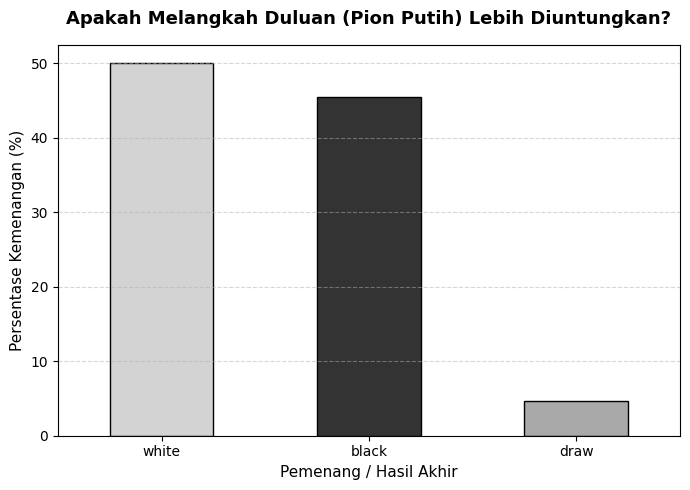

In [17]:
# 1. Hitung total dan persentase kemenangan
win_counts = df['winner'].value_counts()
win_percentages = df['winner'].value_counts(normalize=True) * 100

# Menampilkan hasil teks di terminal/notebook
print("--- HASIL ANALISIS KEMENANGAN ---")
for status, percent in win_percentages.items():
    print(f"Peluang {status.capitalize()} : {percent:.2f}% ({win_counts[status]} pertandingan)")

# 2. Visualisasi dengan Bar Chart
warna_pion = {
    'white': 'lightgray',
    'black': '#333333',
    'draw': 'darkgray'
}
colors = [warna_pion[status] for status in win_percentages.index]

# Plotting grafik batang vertikal
win_percentages.plot(kind='bar', color=colors, edgecolor='black', figsize=(7, 5))

# Kustomisasi Tampilan Grafik
plt.title('Apakah Melangkah Duluan (Pion Putih) Lebih Diuntungkan?', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Pemenang / Hasil Akhir', fontsize=11)
plt.ylabel('Persentase Kemenangan (%)', fontsize=11)
plt.xticks(rotation=0) # Memaksa teks 'white', 'black', 'draw' tetap tegak lurus
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2. Pembukaan apa yang memiliki persentase kemenangan yang tinggi?

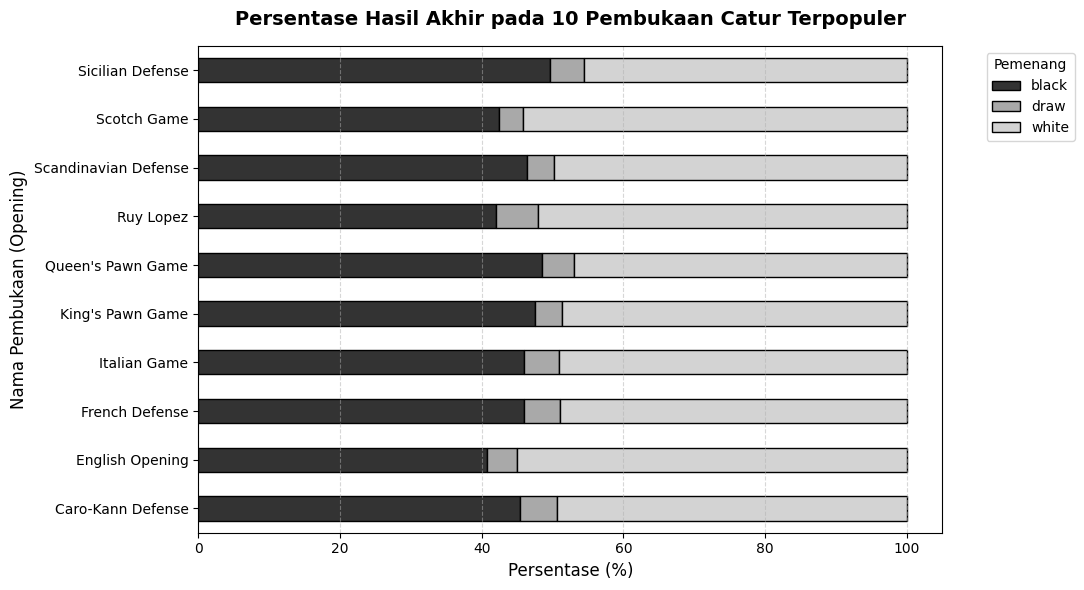

In [20]:
# 1. Ambil nama 10 pembukaan yang paling populer/sering muncul
top_10_openings = df['opening_name_clean'].value_counts().head(10).index

# 2. Saring DataFrame utama agar hanya menyisakan 10 pembukaan populer tersebut
df_top_openings = df[df['opening_name_clean'].isin(top_10_openings)]

# 3. Buat crosstab persentase dari data yang sudah disaring
crosstab_populer = pd.crosstab(
    df_top_openings['opening_name_clean'],
    df_top_openings['winner'],
    normalize='index'
) * 100

# 4. Plotting Stacked Bar Chart
crosstab_populer.plot(
    kind='barh',
    stacked=True,
    color=['#333333', 'darkgray', 'lightgray'],
    edgecolor='black',
    figsize=(11, 6)
)

# Kustomisasi Grafis
plt.title('Persentase Hasil Akhir pada 10 Pembukaan Catur Terpopuler', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Persentase (%)', fontsize=12)
plt.ylabel('Nama Pembukaan (Opening)', fontsize=12)
plt.legend(title='Pemenang', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3. Apakah selisih rating yang besar mempercepat durasi pertandingan?

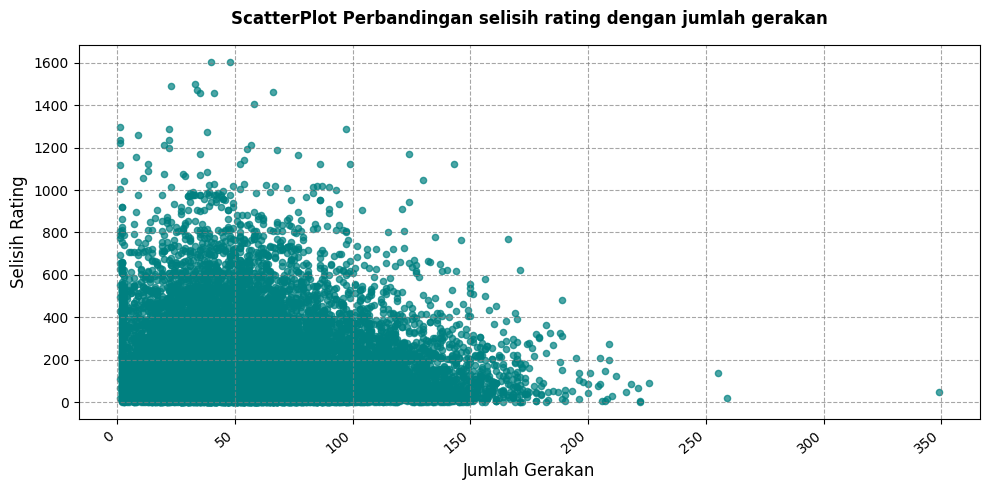

In [24]:
# 1. Membuat kolom baru bernama rating_difference
df['rating_difference'] = (df['white_rating'] - df['black_rating']).abs()

# 2. visualisasi
(
    df.plot(kind="scatter",
            x='turns',
            y='rating_difference',
            alpha=0.7,
            figsize=(10,5),
            color='teal')
)

plt.title('ScatterPlot Perbandingan selisih rating dengan jumlah gerakan', fontsize=12, fontweight='bold', pad = 15)
plt.xlabel('Jumlah Gerakan', fontsize=12)
plt.ylabel('Selisih Rating', fontsize=12)
plt.grid(linestyle='--', alpha=0.7, color='gray')
plt.xticks(rotation=40, ha='right')

plt.tight_layout()
plt.show()